In [1]:
import glob, io
import numpy as np
import pandas as pd
from sqlalchemy import create_engine, text

engine = create_engine("postgresql+psycopg2://postgres@127.0.0.1:5432/trading")


In [2]:
# Same backtester as notebook 03 (all 7 tests passed there)
import numpy as np
import pandas as pd

PIP = 0.0001
COST_PIPS = 1.4          # spread + slippage, round trip (from the specs)

def simulate_trade(bars, entry_i, side, stop, target, max_bars=None, exit_time=None):
    """
    bars:      DataFrame with open/high/low/close, index = bar start time (UTC)
    entry_i:   integer position of the bar we ENTER on (fill at its open)
    side:      +1 long, -1 short
    stop, target: absolute prices
    max_bars:  close at that bar's close if still open after this many bars
    exit_time: 'HH:MM' UTC, close at the open of the first bar at/after this time
    Returns a dict describing the trade, with P&L in pips after costs.
    """
    entry_px = bars["open"].iat[entry_i]
    n = len(bars)
    for k, i in enumerate(range(entry_i, n)):
        t = bars.index[i]
        o, h, l, c = bars["open"].iat[i], bars["high"].iat[i], bars["low"].iat[i], bars["close"].iat[i]

        # time exit: leave at this bar's open
        if exit_time is not None and k > 0 and t.strftime("%H:%M") >= exit_time:
            exit_px, reason = o, "time"
            break

        if side == 1:
            hit_stop, hit_tgt = l <= stop, h >= target
        else:
            hit_stop, hit_tgt = h >= stop, l <= target

        if hit_stop:                       # checked FIRST: worst case if both touched
            # if the bar opened beyond the stop (a gap), we fill at the open, not the stop
            gap = (o < stop) if side == 1 else (o > stop)
            exit_px, reason = (o if gap else stop), "stop"
            break
        if hit_tgt:
            exit_px, reason = target, "target"
            break
        if max_bars is not None and k + 1 >= max_bars:
            exit_px, reason = c, "max_bars"
            break
    else:
        exit_px, reason, i = bars["close"].iat[n - 1], "end_of_data", n - 1

    gross = side * (exit_px - entry_px) / PIP
    return {
        "entry_time": bars.index[entry_i], "exit_time": bars.index[i],
        "side": side, "entry": entry_px, "exit": exit_px, "reason": reason,
        "bars_held": i - entry_i + 1,
        "pips_gross": gross, "pips_net": gross - COST_PIPS,
        "risk_pips": abs(entry_px - stop) / PIP,
    }

In [3]:
# Strategy A and B exactly as in notebooks 04 and 05
def run_strategy_a(b15, b60, stop_mult=1.0, tgt_mult=2.0):
    trades, skipped = [], {"no_data": 0, "range_too_wide": 0, "range_too_narrow": 0, "no_breakout": 0}
    pos = {t: i for i, t in enumerate(b15.index)}          # timestamp -> row number

    asia_rng = (b15.between_time("00:00", "06:45")
                  .groupby(b15.between_time("00:00", "06:45").index.normalize())
                  .agg(hi=("high", "max"), lo=("low", "min")))
    asia_rng["rng"] = asia_rng["hi"] - asia_rng["lo"]
    asia_rng["cap"] = asia_rng["rng"].shift(1).rolling(60, min_periods=40).quantile(0.80)

    for day, g in b15.groupby(b15.index.normalize()):
        asia = g.between_time("00:00", "06:45")
        london = g.between_time("07:00", "10:45")
        atr_bar = day + pd.Timedelta(hours=6)              # 06:00 1h bar, finished at 07:00
        if len(asia) < 20 or london.empty or atr_bar not in b60.index:
            skipped["no_data"] += 1; continue

        hi, lo = asia["high"].max(), asia["low"].min()
        atr = b60.at[atr_bar, "atr_14"]
        rng = hi - lo
        cap = asia_rng["cap"].get(day, np.nan)
        if np.isnan(cap) or np.isnan(atr):  skipped["no_data"] += 1;        continue
        if rng > cap:                       skipped["range_too_wide"] += 1; continue
        if rng < 10 * PIP:       skipped["range_too_narrow"] += 1; continue

        signal = None
        for t, row in london.iterrows():
            if row["close"] > hi: signal = (t, 1);  break
            if row["close"] < lo: signal = (t, -1); break
        if signal is None:
            skipped["no_breakout"] += 1; continue

        t, side = signal
        entry_i = pos[t] + 1                                # fill at the NEXT bar's open
        if entry_i >= len(b15) or b15.index[entry_i].normalize() != day:
            skipped["no_data"] += 1; continue
        entry_px = b15["open"].iat[entry_i]
        stop   = entry_px - side * stop_mult * atr
        target = entry_px + side * tgt_mult * atr
        tr = simulate_trade(b15, entry_i, side, stop, target, exit_time="16:00")
        tr["atr_pips"] = atr / PIP
        trades.append(tr)

    return pd.DataFrame(trades), skipped


def run_strategy_b(b60, band=2.0, stop_mult=1.5, max_bars=8):
    trades, skipped = [], {"no_data": 0, "high_vol": 0, "target_wrong_side": 0}
    upper = b60["ma20"] + band * b60["sd20"]
    lower = b60["ma20"] - band * b60["sd20"]
    i, n = 0, len(b60)
    while i < n - 1:
        t = b60.index[i]
        c = b60["close"].iat[i]
        side = 1 if c < lower.iat[i] else (-1 if c > upper.iat[i] else 0)
        if side == 0 or t.hour >= 7:                  # signal bar must START in 00:00-06:00 UTC
            i += 1; continue
        atr, cap, ma = b60["atr_14"].iat[i], b60["atr_cap"].iat[i], b60["ma20"].iat[i]
        if np.isnan(atr) or np.isnan(cap) or np.isnan(ma):
            skipped["no_data"] += 1; i += 1; continue
        if atr > cap:
            skipped["high_vol"] += 1; i += 1; continue
        entry_i = i + 1                                # fill at the NEXT bar's open
        entry_px = b60["open"].iat[entry_i]
        target = ma                                    # fixed at signal time
        if side * (target - entry_px) <= 0:            # already snapped back by the open
            skipped["target_wrong_side"] += 1; i += 1; continue
        stop = entry_px - side * stop_mult * atr
        tr = simulate_trade(b60, entry_i, side, stop, target, max_bars=max_bars)
        trades.append(tr)
        i = b60.index.get_loc(tr["exit_time"]) + 1     # one position at a time
    return pd.DataFrame(trades), skipped


def add_b_features(b60):
    b60 = b60.copy()
    b60["ma20"] = b60["close"].rolling(20).mean()
    b60["sd20"] = b60["close"].rolling(20).std()
    b60["atr_cap"] = b60["atr_14"].shift(1).rolling(60 * 24, min_periods=500).quantile(0.80)
    return b60

def load_bars(pair, tf):
    b = pd.read_sql(
        "SELECT ts_utc, open, high, low, close, atr_14, session FROM fx_bars "
        "WHERE pair = %(p)s AND timeframe = %(tf)s ORDER BY ts_utc",
        engine, params={"p": pair, "tf": tf}, index_col="ts_utc",
    )
    b.index = pd.to_datetime(b.index, utc=True)
    return b

def summarize(tr, label):
    R = tr["pips_net"] / tr["risk_pips"]
    Rg = tr["pips_gross"] / tr["risk_pips"]
    n = len(tr)
    return {"test": label, "trades": n,
            "win_rate": round((tr.pips_net > 0).mean(), 3),
            "avg_R": round(R.mean(), 3),
            "se": round(R.std() / np.sqrt(n), 3),   # rough +/- noise on avg_R
            "avg_R_before_costs": round(Rg.mean(), 3),
            "total_R": round(R.sum(), 1)}


## Part 1 · Load GBPUSD

In [4]:
files = sorted(glob.glob("../data/raw/DAT_ASCII_GBPUSD_M1_*.csv"))
cols = ["ts", "open", "high", "low", "close", "volume"]
g = pd.concat((pd.read_csv(f, sep=";", header=None, names=cols) for f in files), ignore_index=True)

g["ts_utc"] = (pd.to_datetime(g["ts"], format="%Y%m%d %H%M%S") + pd.Timedelta(hours=5)).dt.tz_localize("UTC")
g["pair"] = "GBPUSD"
g = g[["pair", "ts_utc", "open", "high", "low", "close", "volume"]]

print(len(files), "files,", len(g), "rows")
print("duplicates:", g.duplicated(["pair", "ts_utc"]).sum())
print("nulls:", int(g.isna().sum().sum()))
print("bad bars:", ((g.high < g.low) | (g.close > g.high) | (g.close < g.low)).sum())
g = g.drop_duplicates(["pair", "ts_utc"], keep="first").reset_index(drop=True)
print(len(g), "rows after dedupe |", g.ts_utc.min(), "to", g.ts_utc.max())


11 files, 4042186 rows
duplicates: 420
nulls: 0
bad bars: 0
4041766 rows after dedupe | 2015-01-01 18:01:00+00:00 to 2025-12-31 21:57:00+00:00


In [5]:
# Replace any old GBPUSD rows, then bulk-load with COPY (EURUSD rows are untouched)
with engine.begin() as conn:
    conn.execute(text("DELETE FROM fx_m1 WHERE pair = 'GBPUSD'"))

buf = io.StringIO()
g.to_csv(buf, index=False, header=False)
buf.seek(0)
raw = engine.raw_connection()
try:
    with raw.cursor() as cur:
        cur.copy_expert("COPY fx_m1 (pair, ts_utc, open, high, low, close, volume) FROM STDIN WITH (FORMAT csv)", buf)
    raw.commit()
finally:
    raw.close()

pd.read_sql("SELECT pair, COUNT(*) AS n, MIN(ts_utc), MAX(ts_utc) FROM fx_m1 GROUP BY pair", engine)


,pair,n,min,max
0,EURUSD,4043104,2015-01-01 18:00:00+00:00,2025-12-31 21:57:00+00:00
1,GBPUSD,4041766,2015-01-01 18:01:00+00:00,2025-12-31 21:57:00+00:00


In [6]:
# Coverage check: worst months, and the Mar-Jul 2023 hours vs the same months of 2022
m = pd.read_sql("""
    SELECT date_trunc('month', ts_utc) AS month, COUNT(*) AS bars
    FROM fx_m1 WHERE pair = 'GBPUSD' GROUP BY 1 ORDER BY 1""", engine)
m["weekdays"] = m["month"].apply(lambda d: len(pd.bdate_range(d, d + pd.offsets.MonthEnd(0))))
m["coverage"] = (m["bars"] / (m["weekdays"] * 1440)).round(3)
print(m.sort_values("coverage").head(8).to_string(index=False))

h = pd.read_sql("""
    SELECT EXTRACT(hour FROM ts_utc AT TIME ZONE 'UTC') AS hour_utc,
           COUNT(*) FILTER (WHERE ts_utc >= '2023-03-01' AND ts_utc < '2023-08-01') AS gap_period,
           COUNT(*) FILTER (WHERE ts_utc >= '2022-03-01' AND ts_utc < '2022-08-01') AS same_months_2022
    FROM fx_m1 WHERE pair = 'GBPUSD' GROUP BY 1 ORDER BY 1""", engine)
h["ratio"] = (h["gap_period"] / h["same_months_2022"]).round(2)
print(h.to_string(index=False))


                    month  bars  weekdays  coverage
2023-04-01 04:00:00+00:00 19735        20     0.685
2023-06-01 04:00:00+00:00 21969        22     0.693
2023-03-01 04:00:00+00:00 23007        23     0.695
2023-05-01 04:00:00+00:00 23310        23     0.704
2023-07-01 04:00:00+00:00 22031        21     0.729
2023-02-01 04:00:00+00:00 25685        20     0.892
2017-12-01 04:00:00+00:00 28266        21     0.935
2015-12-01 04:00:00+00:00 31080        23     0.938
 hour_utc  gap_period  same_months_2022  ratio
      0.0        3692              6472   0.57
      1.0        6479              6539   0.99
      2.0        6480              6539   0.99
      3.0        6480              6540   0.99
      4.0        6480              6540   0.99
      5.0        6478              6540   0.99
      6.0        6479              6540   0.99
      7.0        6480              6540   0.99
      8.0        6480              6540   0.99
      9.0        6300              6540   0.96
     10.0      

In [7]:
# Same decision as EURUSD: flag Mar-Jul 2023 so it is left out of the bars
with engine.begin() as conn:
    conn.execute(text("""
        UPDATE fx_m1 SET bad_period = (ts_utc >= '2023-03-01' AND ts_utc < '2023-08-01')
        WHERE pair = 'GBPUSD'"""))
pd.read_sql("SELECT pair, bad_period, COUNT(*) FROM fx_m1 GROUP BY 1, 2 ORDER BY 1, 2", engine)


,pair,bad_period,count
0,EURUSD,False,3932734
1,EURUSD,True,110370
2,GBPUSD,False,3931714
3,GBPUSD,True,110052


In [8]:
# Build GBPUSD 15m and 1h bars (same recipe as notebook 02) and add them to fx_bars
m1 = pd.read_sql("SELECT ts_utc, open, high, low, close FROM fx_m1 "
                 "WHERE pair = 'GBPUSD' AND NOT bad_period ORDER BY ts_utc",
                 engine, index_col="ts_utc")
m1.index = pd.to_datetime(m1.index, utc=True)

def make_bars(m1, rule, minutes):
    bars = m1.resample(rule, label="left", closed="left").agg(
        {"open": "first", "high": "max", "low": "min", "close": "last"})
    bars["n_min"] = m1["close"].resample(rule, label="left", closed="left").count()
    return bars[bars["n_min"] >= 0.5 * minutes].copy()

def session(hour):
    if 0 <= hour < 7:   return "asia"
    if 7 <= hour < 12:  return "london"
    if 12 <= hour < 16: return "overlap"
    if 16 <= hour < 21: return "newyork"
    return "late"

def add_features(b):
    prev_close = b["close"].shift(1)
    tr = pd.concat([b["high"] - b["low"], (b["high"] - prev_close).abs(),
                    (b["low"] - prev_close).abs()], axis=1).max(axis=1)
    b["atr_14"] = tr.rolling(14).mean()
    b["session"] = [session(x) for x in b.index.hour]
    return b

out = []
for tf, rule, mins in [("15m", "15min", 15), ("1h", "1h", 60)]:
    t = add_features(make_bars(m1, rule, mins)).reset_index().rename(columns={"index": "ts_utc"})
    t.insert(0, "timeframe", tf)
    t.insert(0, "pair", "GBPUSD")
    out.append(t)
gbars = pd.concat(out, ignore_index=True)

with engine.begin() as conn:
    conn.execute(text("DELETE FROM fx_bars WHERE pair = 'GBPUSD'"))
gbars.to_sql("fx_bars", engine, if_exists="append", index=False, chunksize=10_000, method="multi")
pd.read_sql("SELECT pair, timeframe, COUNT(*) FROM fx_bars GROUP BY 1, 2 ORDER BY 1, 2", engine)


,pair,timeframe,count
0,EURUSD,15m,263020
1,EURUSD,1h,65773
2,GBPUSD,15m,262946
3,GBPUSD,1h,65764


## Part 2 · Monte Carlo reshuffle (Strategy B, 2015–2023)

Same trades, random order, 1,000 times. The average R never changes when you shuffle, but the worst losing streak does. This shows the range of drawdowns you could have lived through by luck alone, at 1% risk per trade.

In [9]:
e15, e60 = load_bars("EURUSD", "15m"), add_b_features(load_bars("EURUSD", "1h"))
dev = e60[e60.index < "2024-01-01"]                      # build + validation only
trB_dev, _ = run_strategy_b(dev, band=1.5, stop_mult=2.0)
R_dev = (trB_dev["pips_net"] / trB_dev["risk_pips"]).to_numpy()
print(len(R_dev), "trades | avg R", round(R_dev.mean(), 3))

def max_drawdown_pct(R, risk=0.01):
    equity = np.cumprod(1 + risk * R)                    # compounding at 1% risk per trade
    peak = np.maximum.accumulate(np.r_[1.0, equity])[1:]
    return ((equity / peak) - 1).min()

rng = np.random.default_rng(42)
actual_dd = max_drawdown_pct(R_dev)
sims = np.array([max_drawdown_pct(rng.permutation(R_dev)) for _ in range(1000)])
print(f"actual order max drawdown: {actual_dd:.1%}")
print("reshuffled max drawdown percentiles:")
print(pd.Series(sims).quantile([0.05, 0.25, 0.5, 0.75, 0.95]).map("{:.1%}".format))
print(f"final equity (any order): {np.prod(1 + 0.01 * R_dev) - 1:+.1%}")


654 trades | avg R -0.033
actual order max drawdown: -27.8%
reshuffled max drawdown percentiles:
0.05    -37.1%
0.25    -32.4%
0.50    -29.5%
0.75    -27.0%
0.95    -23.8%
dtype: str
final equity (any order): -21.2%


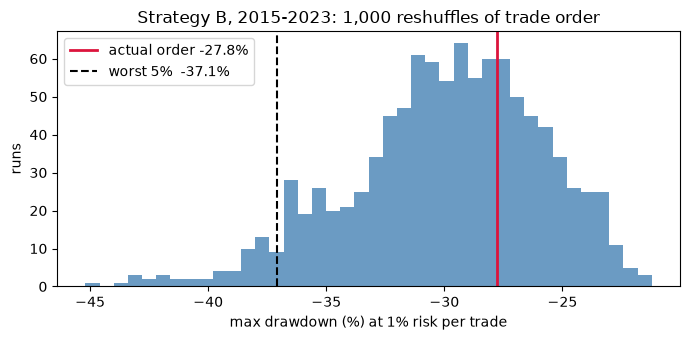

In [10]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(sims * 100, bins=40, color="steelblue", alpha=0.8)
ax.axvline(actual_dd * 100, color="crimson", lw=2, label=f"actual order {actual_dd:.1%}")
ax.axvline(np.percentile(sims, 5) * 100, color="black", ls="--", label=f"worst 5%  {np.percentile(sims, 5):.1%}")
ax.set_xlabel("max drawdown (%) at 1% risk per trade"); ax.set_ylabel("runs")
ax.set_title("Strategy B, 2015-2023: 1,000 reshuffles of trade order")
ax.legend(); plt.tight_layout()
plt.savefig("../reports/monte_carlo_dd.png", dpi=120); plt.show()


## Part 3 · FINAL TEST — run this once

2024–2025 has not been touched by any earlier notebook. Indicators are computed on the full history (they only look backward), and only trades **entered** in 2024–2025 are counted. Whatever comes out is the answer; no changes afterwards.

In [11]:
TEST_START = "2024-01-01"

# Strategy B on EURUSD (band 1.5, stop 2.0, no ML)
trB_test, _ = run_strategy_b(e60[e60.index >= "2023-10-01"], band=1.5, stop_mult=2.0)
trB_test = trB_test[trB_test.entry_time >= TEST_START]

# Strategy A on EURUSD (base spec 1.0 / 2.0), with a 3-month warm-up for the 60-day range filter
w15 = e15[e15.index >= "2023-10-01"]
w60 = load_bars("EURUSD", "1h"); w60 = w60[w60.index >= "2023-10-01"]
trA_test, _ = run_strategy_a(w15, w60, stop_mult=1.0, tgt_mult=2.0)
trA_test = trA_test[trA_test.entry_time >= TEST_START]

# Strategy B on GBPUSD, same settings, no retuning
g60 = add_b_features(load_bars("GBPUSD", "1h"))
trG_all, _ = run_strategy_b(g60, band=1.5, stop_mult=2.0)
trG_test = trG_all[trG_all.entry_time >= TEST_START]
trG_dev = trG_all[trG_all.entry_time < TEST_START]

final = pd.DataFrame([
    summarize(trA_test, "A  EURUSD 2024-25"),
    summarize(trB_test, "B  EURUSD 2024-25"),
    summarize(trG_test, "B  GBPUSD 2024-25"),
    summarize(trG_dev,  "B  GBPUSD 2015-23"),
    summarize(trB_dev,  "B  EURUSD 2015-23 (reference)"),
])
final


,test,trades,win_rate,avg_R,se,avg_R_before_costs,total_R
0,A EURUSD 2024-25,343,0.338,-0.178,0.076,0.002,-61.1
1,B EURUSD 2024-25,179,0.615,0.049,0.059,0.118,8.8
2,B GBPUSD 2024-25,165,0.527,-0.104,0.064,-0.049,-17.1
3,B GBPUSD 2015-23,586,0.532,-0.069,0.034,-0.024,-40.4
4,B EURUSD 2015-23 (reference),654,0.531,-0.033,0.032,0.029,-21.7


In [12]:
# By year, and how sensitive B is to a wider spread (GBPUSD usually costs more than EURUSD)
for name, tr in [("A EURUSD", trA_test), ("B EURUSD", trB_test), ("B GBPUSD", trG_test)]:
    t = tr.assign(R=tr.pips_net / tr.risk_pips, year=tr.entry_time.dt.year)
    print(name, t.groupby("year")["R"].agg(["count", "mean"]).round(3).to_dict("index"))

for cost in [1.0, 1.4, 2.0]:
    row = {"cost_pips": cost}
    for name, tr in [("B EURUSD 24-25", trB_test), ("B GBPUSD 24-25", trG_test), ("B GBPUSD 15-23", trG_dev)]:
        row[name] = round(((tr.pips_gross - cost) / tr.risk_pips).mean(), 3)
    print(row)


A EURUSD {2024: {'count': 166, 'mean': -0.23}, 2025: {'count': 177, 'mean': -0.129}}
B EURUSD {2024: {'count': 81, 'mean': 0.101}, 2025: {'count': 98, 'mean': 0.006}}
B GBPUSD {2024: {'count': 67, 'mean': 0.01}, 2025: {'count': 98, 'mean': -0.181}}
{'cost_pips': 1.0, 'B EURUSD 24-25': np.float64(0.069), 'B GBPUSD 24-25': np.float64(-0.088), 'B GBPUSD 15-23': np.float64(-0.056)}
{'cost_pips': 1.4, 'B EURUSD 24-25': np.float64(0.049), 'B GBPUSD 24-25': np.float64(-0.104), 'B GBPUSD 15-23': np.float64(-0.069)}
{'cost_pips': 2.0, 'B EURUSD 24-25': np.float64(0.02), 'B GBPUSD 24-25': np.float64(-0.127), 'B GBPUSD 15-23': np.float64(-0.088)}


In [13]:
# Monte Carlo on the final-test trades too (B, EURUSD 2024-25)
R_test = (trB_test["pips_net"] / trB_test["risk_pips"]).to_numpy()
sims_t = np.array([max_drawdown_pct(rng.permutation(R_test)) for _ in range(1000)])
print(f"actual {max_drawdown_pct(R_test):.1%} | median {np.median(sims_t):.1%} | worst 5% {np.percentile(sims_t, 5):.1%}")
print(f"final equity at 1% risk: {np.prod(1 + 0.01 * R_test) - 1:+.1%}")


actual -6.6% | median -8.3% | worst 5% -12.5%
final equity at 1% risk: +8.6%
